In [28]:
#SOLVE LAPLACIAN = 10e34 at center
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
#stretch in z*
# Nx=10
# np.fft.fftfreq(Nx)

In [29]:
#INVERTING LAPLACIAN FUNCTION
import numpy as np

def invert_laplacian_1d(RHS, dx):
    """
    Solve LHS = ∇²Φ = RHS in Fourier space using the inverse Laplacian.
    
    Parameters:
        RHS : 1D array
            The right-hand side of the equation in the spatial domain.
        dx, dy : float
            Grid spacings in the x and y directions.
    
    Returns:
        LHS : 1D array
            The solution Φ in the spatial domain.
    """
    # Generate wavevectors
    kx = (2*np.pi)* np.fft.fftfreq(Nx, d=dx) #includes /Nx term
    # kx = np.concatenate([np.arange(0, Nx // 2 + 1), np.arange(-Nx // 2 + 1, 0)])
    
    # # Create a 1D grid of wavevector magnitudes
    K_squared = (kx**2)

    # Perform Fourier Transform on the RHS
    RHS_fft = np.fft.fft(RHS)
    
    # Initialize the transformed LHS
    LHS_fft = np.zeros_like(RHS_fft, dtype=complex)
    
    # Avoid division by zero for the zero-frequency mode
    non_zero = K_squared !=0
    LHS_fft[non_zero] = RHS_fft[non_zero] / (-K_squared[non_zero])
    
    
    # Perform the inverse FFT to get the solution in the spatial domain
    LHS = np.fft.ifft(LHS_fft).real  # Take the real part to eliminate numerical noise
    
    return LHS,RHS_fft


# def laplacian_fft(f, dx):
#     # Compute the 2D Fourier transform of the function
#     f_fft = np.fft.fft(f)
    
#     # Generate the wavevectors (with handling of 0 frequency)
#     kx = 2 * np.pi * np.fft.fftfreq(Nx, d=dx)
#     K = kx**2
    
#     # Apply the Laplacian in Fourier space
#     f_laplacian_fft = -K * f_fft
    
#     # Inverse FFT to get the Laplacian in the spatial domain
#     f_laplacian = np.fft.ifft(f_laplacian_fft)
    
#     return np.real(f_laplacian)
def compute_laplacian_1d(f, dx):
    # Initialize the second derivatives arrays with zeros, same shape as f
    d2f_dx2 = np.zeros_like(f)
    
    # Second derivatives using central differences
    d2f_dx2[1:-1] = (f[:-2] - 2 * f[1:-1] + f[2:]) / dx**2
    
    # Combine to reconstruct the Laplacian (RHS)
    RHS_reconstructed = d2f_dx2
    
    return RHS_reconstructed 

In [30]:
# fig=plt.figure(figsize=(14*1.5,6))
# gs=gridspec.GridSpec(nrows=1,ncols=4,figure=fig)
# ax0=fig.add_subplot(gs[0,0])
# ax1=fig.add_subplot(gs[0,1])
# ax2=fig.add_subplot(gs[0,2])
# ax3=fig.add_subplot(gs[0,3])


# #TESTING LAPLACIAN INVERT FUNCTION
# ####################
# Nx = 100
# Lx = 100; dx=Nx/Lx

# x = np.linspace(-Lx, Lx, Nx)
# RHS=x
# RHS[Nx//2]=1e32

# contour0=ax0.plot(RHS)
# ax0.set_ylabel('value');ax0.set_xlabel('x')
# ax0.set_title(f"RHS. max point = {RHS[Nx//2]}")
# ####################

# #####################
# [LHS,RHS_fft]=invert_laplacian_1d(RHS,dx)
# # RHS_fft=np.abs(RHS_fft)
# # LHS=np.real(np.fft.ifft2(np.fft.fft2(RHS)));LHS[LHS<1e-12]=0 #TESTING
# abs_shifted_RHS_fft=np.abs(np.fft.fftshift(RHS_fft))
# contour1=ax1.plot(abs_shifted_RHS_fft)
# ax1.set_title(f"shifted fft of RHS")

# contour1=ax2.plot(LHS)
# ax2.set_title(f"solution for f")
# # ####################

# # ##############################################################################################################################

# ####################
# #TESTING if taking laplacian gives all 1s
# out=LHS
# laplacian_out=compute_laplacian_1d(out, dx)
# # laplacian_out=laplacian_fft(LHS,dx)

# contour2=ax3.plot(laplacian_out) #NOT WORKING CURRENTLY 
# ax3.plot(RHS,linestyle='dashed',color='r')
# array1=laplacian_out[Nx//2]
# array2=RHS[Nx//2]
# nmae = 1- np.mean(np.abs(array1 - array2) / np.abs(array1))
# rmse = np.sqrt(np.mean((array1 - array2) ** 2))
# ax3.set_title(f"Uninverting with FDM. {laplacian_out[Nx//2]*1e2/RHS[Nx//2]:.3f}% of {RHS[Nx//2]} at center.")
# # fig.colorbar(contour2,ax=ax2) 

# ####################
# fig.suptitle(f"Testing " + r'$\nabla^2 f = g$' + f" on 1D array with Nx = {Nx}, Lx = {Lx}, dx = {Nx/Lx:.0f}")
# ax0.set_ylim(top=np.max(RHS)+0.1*np.max(RHS));
# ax3.set_ylim(top=np.max(RHS)+0.1*np.max(RHS));

Text(0.5, 0.98, 'Testing $\\nabla^2 f = g$ on 1D array with Nx = 50, dx = 1')

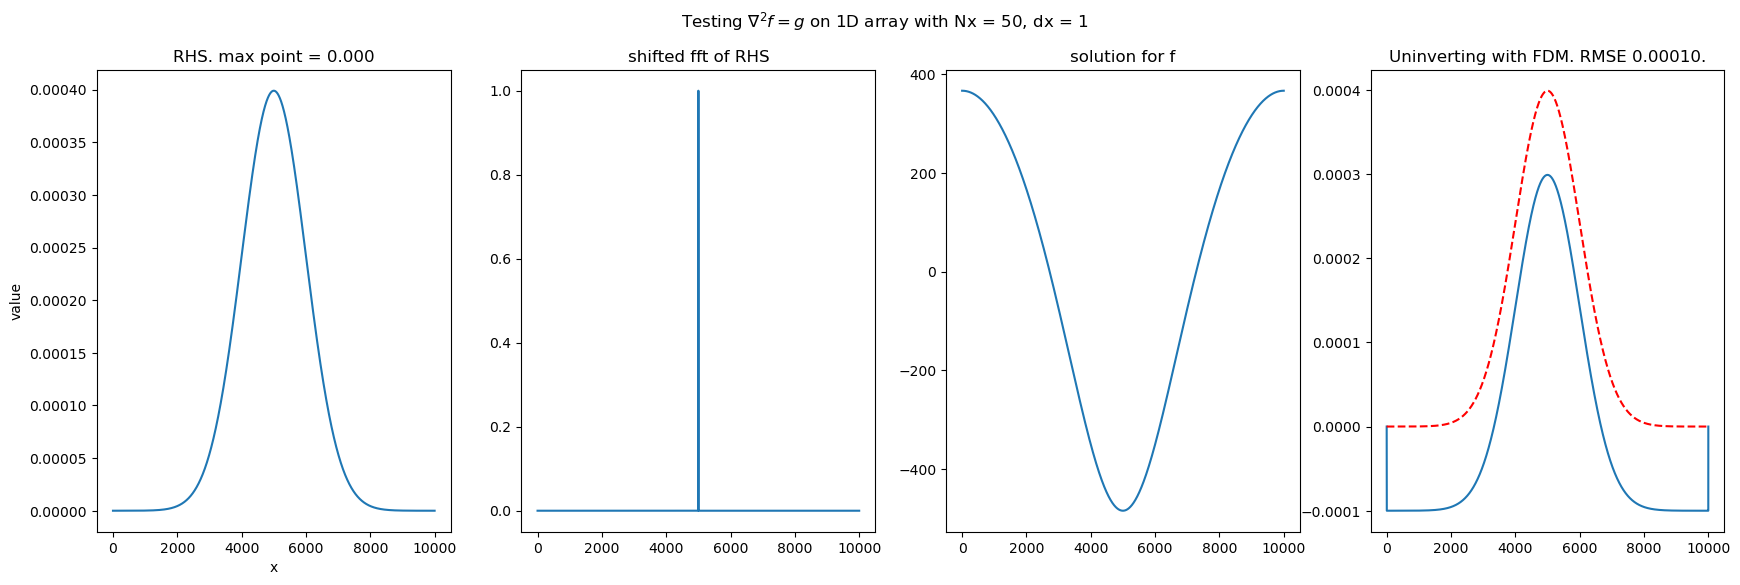

In [31]:
fig=plt.figure(figsize=(14*1.5,6))
gs=gridspec.GridSpec(nrows=1,ncols=4,figure=fig)
ax0=fig.add_subplot(gs[0,0])
ax1=fig.add_subplot(gs[0,1])
ax2=fig.add_subplot(gs[0,2])
ax3=fig.add_subplot(gs[0,3])


#TESTING LAPLACIAN INVERT FUNCTION
####################
Nx = 10000
Lx = 10000; dx=Nx/Lx

# x = np.linspace(-Lx, Lx, Nx)
# a=Lx/10; RHS = np.exp(-a*x**2); RHS/=np.trapz(RHS,x)

x = np.linspace(0, Lx, Nx) #comment out for previous function
a = Lx / 10; RHS = np.exp((-(x-Lx/2)**2)/(2*a**2)); RHS/=np.trapz(RHS,x) #comment out for previous function

contour0=ax0.plot(RHS)
ax0.set_ylabel('value');ax0.set_xlabel('x')
ax0.set_title(f"RHS. max point = {RHS[Nx//2]:.3f}")
####################

#####################
[LHS,RHS_fft]=invert_laplacian_1d(RHS,dx)
# RHS_fft=np.abs(RHS_fft)
# LHS=np.real(np.fft.ifft2(np.fft.fft2(RHS)));LHS[LHS<1e-12]=0 #TESTING
abs_shifted_RHS_fft=np.abs(np.fft.fftshift(RHS_fft))
contour1=ax1.plot(abs_shifted_RHS_fft)
ax1.set_title(f"shifted fft of RHS")

contour1=ax2.plot(LHS)
ax2.set_title(f"solution for f")
# ####################

# ##############################################################################################################################

####################
#TESTING if taking laplacian gives all 1s
out=LHS
laplacian_out=compute_laplacian_1d(out, dx)
# laplacian_out=laplacian_fft(LHS,dx)

contour2=ax3.plot(laplacian_out) #NOT WORKING CURRENTLY 
ax3.plot(RHS,linestyle='dashed',color='r')
array1=laplacian_out
array2=RHS
rmse = np.sqrt(np.mean((array1 - array2) ** 2))
ax3.set_title(f"Uninverting with FDM. RMSE {rmse:.5f}.")
# fig.colorbar(contour2,ax=ax2) 

####################
fig.suptitle(f"Testing " + r'$\nabla^2 f = g$' + f" on 1D array with Nx = 50, dx = 1")
# ax0.set_ylim(top=np.max(RHS)+0.01);
# ax3.set_ylim(top=np.max(RHS)+0.01);

In [32]:
#INVERTING LAPLACIAN FUNCTION
import numpy as np

def invert_laplacian_2d(RHS, dx, dy):
    """
    Solve LHS = ∇²Φ = RHS in Fourier space using the inverse Laplacian.
    
    Parameters:
        RHS : 2D array
            The right-hand side of the equation in the spatial domain.
        dx, dy : float
            Grid spacings in the x and y directions.
    
    Returns:
        LHS : 2D array
            The solution Φ in the spatial domain.
    """
    
    # Get the shape of the grid
    Nx, Ny = RHS.shape
    
    # Generate wavevectors
    kx =  (2*np.pi)*np.fft.fftfreq(Nx, d=dx) #includes /Nx term
    ky =  (2*np.pi)*np.fft.fftfreq(Ny, d=dy) #includes /Ny term

    # Create a 2D grid of wavevector magnitudes
    kx_grid, ky_grid = np.meshgrid(kx, ky, indexing='ij')
    K_squared = (kx_grid**2 + ky_grid**2)

    # Perform Fourier Transform on the RHS
    RHS_fft = np.fft.fft2(RHS)
    
    # Initialize the transformed LHS
    LHS_fft = np.zeros_like(RHS_fft, dtype=complex)
    
    # Avoid division by zero for the zero-frequency mode
    non_zero = K_squared != 0
    LHS_fft[non_zero] = RHS_fft[non_zero] / (-K_squared[non_zero])
    
    # For the zero-frequency mode, the solution is ambiguous; set to zero
    LHS_fft[~non_zero] = 0.0
    
    # Perform the inverse FFT to get the solution in the spatial domain
    LHS = np.fft.ifft2(LHS_fft).real  # Take the real part to eliminate numerical noise
    
    return LHS


# def laplacian_fft(f, dx, dy):
#     # Compute the 2D Fourier transform of the function
#     f_fft = np.fft.fft2(f)
    
#     # Generate the wavevectors (with handling of 0 frequency)
#     Nx, Ny = f.shape
#     kx = 2 * np.pi * np.fft.fftfreq(Nx, d=dx)
#     ky = 2 * np.pi * np.fft.fftfreq(Ny, d=dy)
#     kx, ky = np.meshgrid(kx, ky, indexing='ij')
#     K = kx**2 + ky**2
    
#     # Apply the Laplacian in Fourier space
#     f_laplacian_fft = -K * f_fft
    
#     # Inverse FFT to get the Laplacian in the spatial domain
#     f_laplacian = np.fft.ifft2(f_laplacian_fft)
    
#     return np.real(f_laplacian)

def compute_laplacian_2d(f, dx, dy):
    # Initialize the second derivatives arrays with zeros, same shape as f
    d2f_dx2 = np.zeros_like(f)
    d2f_dy2 = np.zeros_like(f)
    
    # Second derivatives using central differences
    d2f_dx2[1:-1, :] = (f[:-2, :] - 2 * f[1:-1, :] + f[2:, :]) / dx**2
    d2f_dy2[:, 1:-1] = (f[:, :-2] - 2 * f[:, 1:-1] + f[:, 2:]) / dy**2
    
    # Combine to reconstruct the Laplacian (RHS)
    RHS_reconstructed = d2f_dx2 + d2f_dy2
    
    return RHS_reconstructed 

In [33]:
# fig=plt.figure(figsize=(14*1.5,6))
# gs=gridspec.GridSpec(nrows=1,ncols=4,figure=fig)
# ax0=fig.add_subplot(gs[0,0])
# ax1=fig.add_subplot(gs[0,1])
# ax2=fig.add_subplot(gs[0,2])
# ax3=fig.add_subplot(gs[0,3])


# #TESTING LAPLACIAN INVERT FUNCTION
# Nx = 50; Lx = 50
# Ny = 50; Ly = 50
# dx=Lx/Nx;dy=Ly/Ny

# # Create a 2D grid for the domain

# ####################
# # Create the RHS array (zero everywhere)
# RHS = np.zeros((Nx, Ny))
# RHS[Nx//2,Ny//2]=1e32#1e32

# contour0=ax0.contourf(RHS)
# ax0.set_title(f"RHS. {RHS[Nx//2,Ny//2]} at center.")
# fig.colorbar(contour0,ax=ax0)
# ####################

# ####################
# RHS_fft = np.fft.fft2(RHS)
# contour1=ax1.contourf(RHS_fft)
# ax1.set_title(f"fft of RHS.")
# fig.colorbar(contour1,ax=ax1)
# ####################

# ####################
# LHS=np.real(invert_laplacian_2d(RHS,dx,dy))
# # LHS=np.real(np.fft.ifft2(np.fft.fft2(RHS)));LHS[LHS<1e-12]=0 #TESTING
# contour2=ax2.contourf(LHS)
# ax2.set_title(f"solution for f")
# fig.colorbar(contour2,ax=ax2) 
# ####################

# ##############################################################################################################################

# ####################
# #TESTING if taking laplacian gives all 1s
# out=LHS
# laplacian_out=compute_laplacian_2d(out, dx, dy)
# # laplacian_out=laplacian_fft(LHS,dx,dy)

# contour3=ax3.contourf(laplacian_out) #NOT WORKING CURRENTLY 
# ax3.set_title(f"Uninverting with FDM. {laplacian_out[Nx//2,Ny//2]*1e2/RHS[Nx//2,Ny//2]:.3f}% of {RHS[Nx//2, Ny//2]} at center.")
# fig.colorbar(contour3,ax=ax3) 

# ####################
# fig.suptitle(f"Testing " + r'$\nabla^2 f = g$' + f" on 2D array with Nx,Ny = 50, dx,dy = 1")
# ax0.scatter(Nx//2,Ny//2,color='red',s=2,label='center')
# ax1.scatter(Nx//2,Ny//2,color='red',s=2)
# ax2.scatter(Nx//2,Ny//2,color='red',s=2)
# fig.legend()

# # plt.contourf(laplacian_out[48:52,48:52]);
# # plt.colorbar()
# # plt.title('zoomed in ')
# # plt.scatter(2,2,color='red')

Text(0.5, 0.98, 'Testing $\\nabla^2 f = g$ on 3D array with Nx,Ny = 50,50, dx,dy = 1,1')

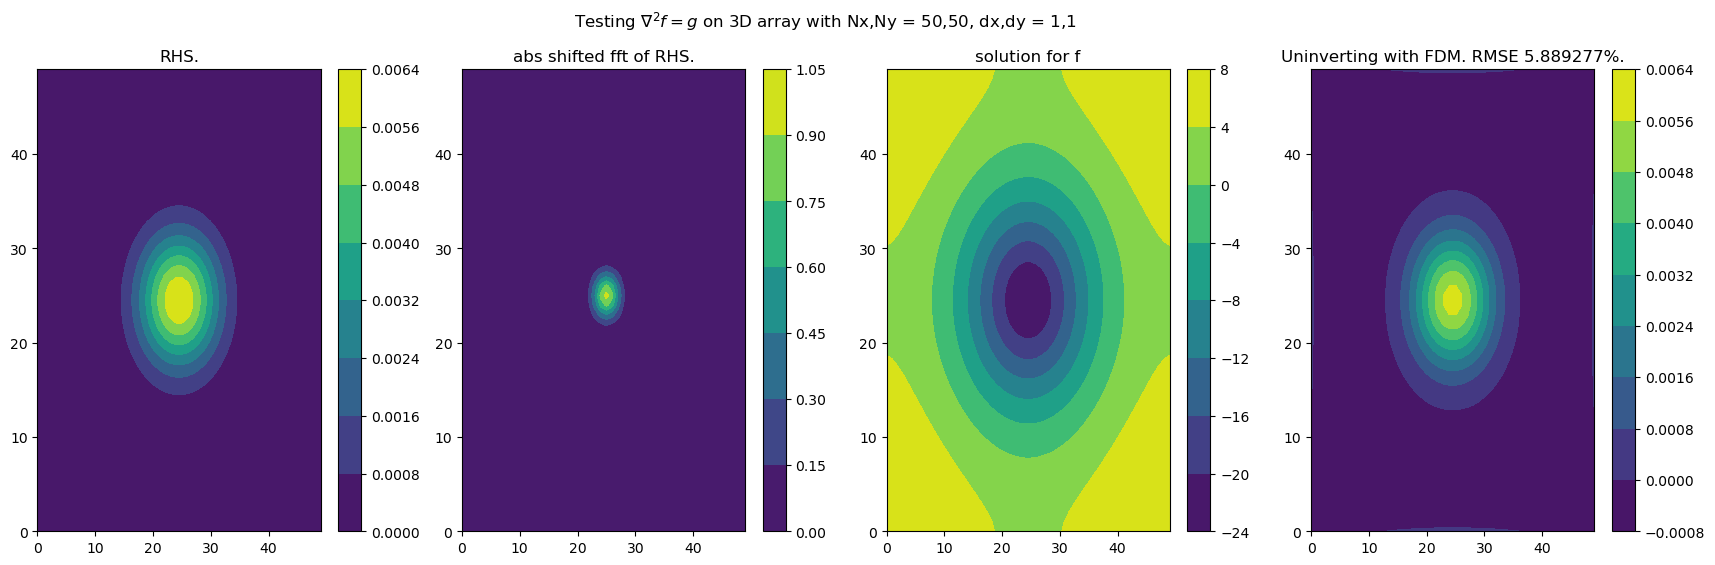

In [34]:
fig=plt.figure(figsize=(14*1.5,6))
gs=gridspec.GridSpec(nrows=1,ncols=4,figure=fig)
ax0=fig.add_subplot(gs[0,0])
ax1=fig.add_subplot(gs[0,1])
ax2=fig.add_subplot(gs[0,2])
ax3=fig.add_subplot(gs[0,3])


#TESTING LAPLACIAN INVERT FUNCTION
Nx = 50; Lx = 50
Ny = 50; Ly = 50
dx=Lx/Nx;dy=Ly/Ny

# Create a 2D grid for the domain

####################
# Create the RHS array (zero everywhere) 
x = np.linspace(0, Lx, Nx)  
y = np.linspace(0, Ly, Ny)
X, Y = np.meshgrid(x, y)  

sigma_x= Lx/10
sigma_y= Ly/10
RHS = np.exp(-((X - Lx / 2)**2 / (2 * sigma_x**2) + (Y - Ly / 2)**2 / (2 * sigma_y**2)))

integral_x = np.trapz(RHS, x, axis=1);integral_y = np.trapz(integral_x, y)   # Integration along y (integrating result over y)
RHS /= integral_y # Normalize RHS such that the integral = 1


contour0=ax0.contourf(RHS)
ax0.set_title(f"RHS.")
fig.colorbar(contour0,ax=ax0)
####################

####################
RHS_fft = np.fft.fft2(RHS)
# contour1=ax1.contourf(RHS_fft)
abs_shifted_RHS_fft=np.abs(np.fft.fftshift(RHS_fft))
contour1=ax1.contourf(abs_shifted_RHS_fft)

ax1.set_title(f"abs shifted fft of RHS.")
fig.colorbar(contour1,ax=ax1)
####################

####################
LHS=np.real(invert_laplacian_2d(RHS,dx,dy))
# contour2=ax2.contourf(LHS)
contour2=ax2.contourf(LHS*integral_y)
ax2.set_title(f"solution for f")
fig.colorbar(contour2,ax=ax2) 
####################

##############################################################################################################################

####################
#TESTING if taking laplacian gives all 1s
out=LHS
laplacian_out=compute_laplacian_2d(out, dx, dy)
# laplacian_out=laplacian_fft(LHS,dx,dy)

contour3=ax3.contourf(laplacian_out) #NOT WORKING CURRENTLY 
array1=laplacian_out
array2=RHS
rmse = np.sqrt(np.mean((array1 - array2) ** 2))*100/np.max(RHS)
ax3.set_title(f"Uninverting with FDM. RMSE {rmse:.6f}%.")
fig.colorbar(contour3,ax=ax3) 

####################
fig.suptitle(f"Testing " + r'$\nabla^2 f = g$' + f" on 3D array with Nx,Ny = {Nx},{Ny}, dx,dy = {Lx/Nx:.0f},{Ly/Ny:.0f}")

# plt.contourf(laplacian_out[48:52,48:52]);
# plt.colorbar()
# plt.title('zoomed in ')
# plt.scatter(2,2,color='red')

In [35]:
#INVERTING LAPLACIAN FUNCTION
import numpy as np

def invert_laplacian_3d(RHS, dx, dy, dz):
    """
    Solve LHS = ∇²Φ = RHS in Fourier space using the inverse Laplacian.
    
    Parameters:
        RHS : 3D array
            The right-hand side of the equation in the spatial domain.
        dx, dy : float
            Grid spacings in the x and y directions.
    
    Returns:
        LHS : 3D array
            The solution Φ in the spatial domain.
    """
    # Get the shape of the grid
    Nx, Ny, Nz = RHS.shape
    
    # Generate wavevectors
    kx = (2 * np.pi) * np.fft.fftfreq(Nx, d=dx) #includes /Nx term
    ky = (2 * np.pi) * np.fft.fftfreq(Ny, d=dy) #includes /Ny term
    kz = (2 * np.pi) *  np.fft.fftfreq(Nz, d=dz) #includes /Ny term

    # Create a 2D grid of wavevector magnitudes
    kx_grid, ky_grid, kz_grid = np.meshgrid(kx, ky, kz, indexing='ij')
    K_squared = (kx_grid**2 + ky_grid**2 + kz_grid**2)

    # Perform Fourier Transform on the RHS
    RHS_fft = np.fft.fftn(RHS)
    
    # Initialize the transformed LHS
    LHS_fft = np.zeros_like(RHS_fft, dtype=complex)
    
    # Avoid division by zero for the zero-frequency mode
    non_zero = K_squared != 0
    LHS_fft[non_zero] = RHS_fft[non_zero] / (-K_squared[non_zero])
    
    # For the zero-frequency mode, the solution is ambiguous; set to zero
    LHS_fft[~non_zero] = 0.0
    
    # Perform the inverse FFT to get the solution in the spatial domain
    LHS = np.fft.ifftn(LHS_fft).real  # Take the real part to eliminate numerical noise
    
    return LHS


def compute_laplacian_3d(f, dx, dy, dz):
    # Initialize the second derivatives arrays with zeros, same shape as f
    d2f_dx2 = np.zeros_like(f)
    d2f_dy2 = np.zeros_like(f)
    d2f_dz2 = np.zeros_like(f)
    
    # Second derivatives using central differences
    d2f_dx2[1:-1, :, :] = (f[:-2, :, :] - 2 * f[1:-1, :, :] + f[2:, :, :]) / dx**2
    d2f_dy2[:, 1:-1, :] = (f[:, :-2, :] - 2 * f[:, 1:-1, :] + f[:, 2:, :]) / dy**2
    d2f_dz2[:, :, 1:-1] = (f[:, :, :-2] - 2 * f[:, :, 1:-1] + f[:, :, 2:]) / dz**2
    
    # Combine to reconstruct the Laplacian (RHS)
    RHS_reconstructed = d2f_dx2 + d2f_dy2 + d2f_dz2
    
    return RHS_reconstructed 



Text(0.5, 0.98, 'Testing $\\nabla^2 f = g$ on 3D array with Nx,Ny,Nz = 50,50,50, dx,dy,dz = 1,1,1')

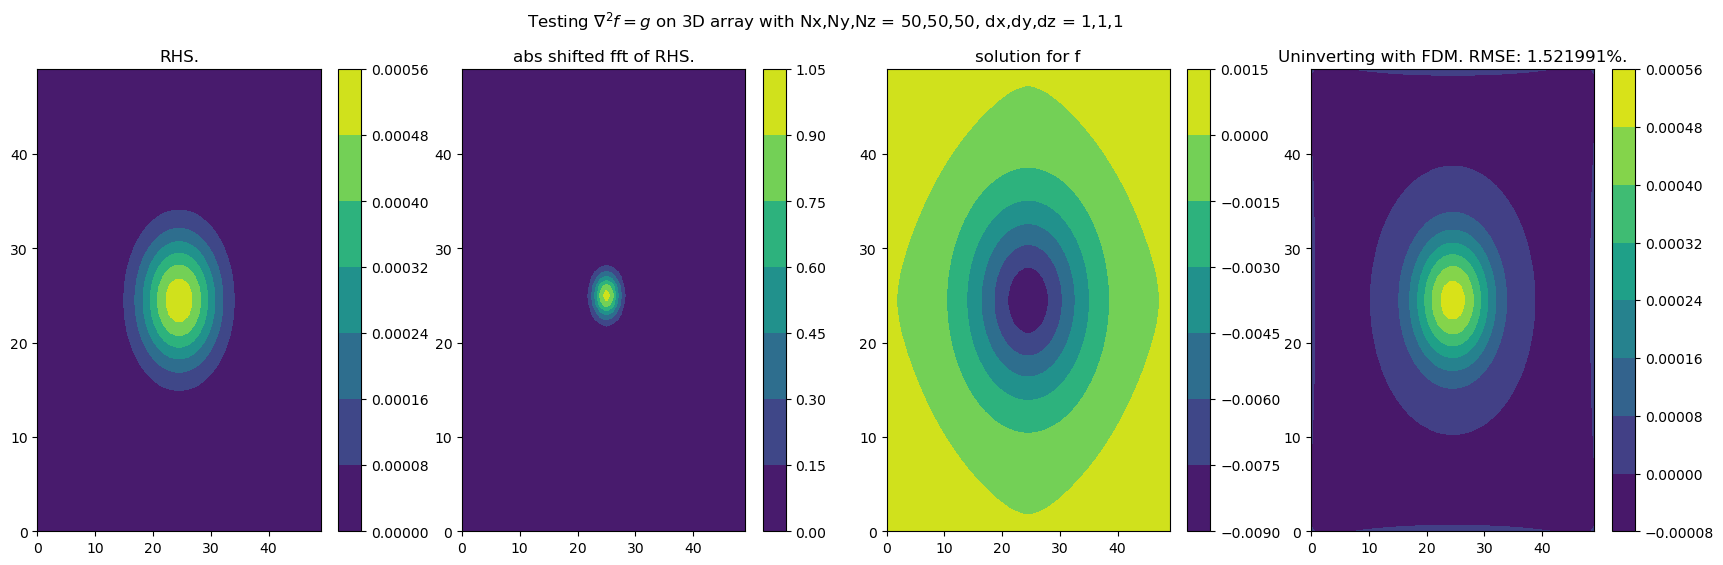

In [36]:
fig=plt.figure(figsize=(14*1.5,6))
gs=gridspec.GridSpec(nrows=1,ncols=4,figure=fig)
ax0=fig.add_subplot(gs[0,0])
ax1=fig.add_subplot(gs[0,1])
ax2=fig.add_subplot(gs[0,2])
ax3=fig.add_subplot(gs[0,3])


#TESTING LAPLACIAN INVERT FUNCTION
Nx = 50; Lx = 50
Ny = 50; Ly = 50
Nz = 50; Lz = 50
dx=Lx/Nx;dy=Ly/Ny;dz=Lz/Nz

# Create a 2D grid for the domain

####################
# Create the RHS array (zero everywhere) 
x = np.linspace(0, Lx, Nx)  
y = np.linspace(0, Ly, Ny)
z = np.linspace(0, Lz, Nz)
X, Y, Z = np.meshgrid(x, y, z)  

sigma_x= Lx/10
sigma_y= Ly/10
sigma_z= Lz/10
RHS = np.exp(-((X - Lx / 2)**2 / (2 * sigma_x**2) + 
               (Y - Ly / 2)**2 / (2 * sigma_y**2) + 
               (Z - Lz / 2)**2 / (2 * sigma_z**2)))

integral_x = np.trapz(RHS, axis=2)
integral_y = np.trapz(integral_x, axis=1)
integral_z = np.trapz(integral_y, axis=0)   
RHS /= integral_z # Normalize RHS such that the integral = 1


contour0=ax0.contourf(RHS[:,:,Nz//2])
ax0.set_title(f"RHS.")
fig.colorbar(contour0,ax=ax0)
####################

####################
RHS_fft = np.fft.fftn(RHS)
# contour1=ax1.contourf(RHS_fft[:,:,Nz//2])
abs_shifted_RHS_fft=np.abs(np.fft.fftshift(RHS_fft))
contour1=ax1.contourf(abs_shifted_RHS_fft[:,:,Nz//2])
ax1.set_title(f"abs shifted fft of RHS.")
fig.colorbar(contour1,ax=ax1)
####################

####################
LHS=np.real(invert_laplacian_3d(RHS,dx,dy,dz))#*integral_z
# LHS=np.real(np.fft.ifft2(np.fft.fft2(RHS)));LHS[LHS<1e-12]=0 #TESTING
contour2=ax2.contourf(LHS[:,:,Nz//2])
ax2.set_title(f"solution for f")
fig.colorbar(contour2,ax=ax2) 
####################

##############################################################################################################################

####################
#TESTING if taking laplacian gives all 1s
out=LHS
laplacian_out=compute_laplacian_3d(out, dx, dy, dz)
# laplacian_out=laplacian_fft(LHS,dx,dy)

contour3=ax3.contourf(laplacian_out[:,:,Nz//2]) #NOT WORKING CURRENTLY 
array1=laplacian_out[:,:,Nz//2]
array2=RHS[:,:,Nz//2]
rmse = np.sqrt(np.mean((array1 - array2) ** 2))*100/np.max(RHS)
ax3.set_title(f"Uninverting with FDM. RMSE: {rmse:.6f}%.")
fig.colorbar(contour3,ax=ax3) 

####################
fig.suptitle(f"Testing " + r'$\nabla^2 f = g$' + f" on 3D array with Nx,Ny,Nz = {Nx},{Nz},{Nz}, dx,dy,dz = {Lx/Nx:.0f},{Ly/Ny:.0f},{Lz/Nz:.0f}")

# plt.contourf(laplacian_out[48:52,48:52]);
# plt.colorbar()
# plt.title('zoomed in ')
# plt.scatter(2,2,color='red')

In [ ]:
#PB and PD

In [37]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

#Importing Model Data
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/Project/'
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
times=data['time'].values/(1e9 * 60); times=times.astype(float);
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
whereCL=xr.open_dataset(dir+'tracking_algorithms/whereCL_4_0622.nc').load() #***
whereCL=whereCL.isel(time=slice(0,len(data['time'])))

#Restricts the timesteps of the data from timesteps0 to 140
data=data.isel(time=np.arange(1,140+1))
parcel=parcel.isel(time=np.arange(1,140+1))

In [83]:
#INVERTING LAPLACIAN FUNCTION
import numpy as np

def invert_laplacian_3d(RHS, dx, dy, dz):
    """
    Solve LHS = ∇²Φ = RHS in Fourier space using the inverse Laplacian.
    
    Parameters:
        RHS : 3D array
            The right-hand side of the equation in the spatial domain.
        dx, dy : float
            Grid spacings in the x and y directions.
    
    Returns:
        LHS : 3D array
            The solution Φ in the spatial domain.
    """
    
    # Get the shape of the grid
    Nx, Ny, Nz = RHS.shape
    
    # Generate wavevectors
    kx = (2 * np.pi) * np.fft.fftfreq(Nx, d=dx) #includes /Nx term
    ky = (2 * np.pi) * np.fft.fftfreq(Ny, d=dy) #includes /Ny term
    kz = (2 * np.pi) *  np.fft.fftfreq(Nz, d=dz) #includes /Ny term

    # Create a 2D grid of wavevector magnitudes
    kx_grid, ky_grid, kz_grid = np.meshgrid(kx, ky, kz, indexing='ij')
    K_squared = (kx_grid**2 + ky_grid**2 + kz_grid**2)

    # Perform Fourier Transform on the RHS
    RHS_fft = np.fft.fftn(RHS)
    RHS_fft*=-1j*kz_grid #TESTING***. 
    
    # Initialize the transformed LHS
    LHS_fft = np.zeros_like(RHS_fft, dtype=complex)
    
    # Avoid division by zero for the zero-frequency mode
    non_zero = K_squared != 0
    LHS_fft[non_zero] = RHS_fft[non_zero] / (-K_squared[non_zero])
    
    # For the zero-frequency mode, the solution is ambiguous; set to zero
    LHS_fft[~non_zero] = 0.0
    
    # Perform the inverse FFT to get the solution in the spatial domain

    LHS = np.fft.ifftn(LHS_fft).real  # Take the real part to eliminate numerical noise
    
    return LHS

def compute_laplacian_3d(f, dx, dy):
    # Initialize the second derivatives arrays with zeros, same shape as f
    #f must be interpolated to cell centers
    dz=np.diff(data['zf'].values)
    dz=dz.copy()[:, np.newaxis, np.newaxis]
    
    d2f_dx2 = np.zeros_like(f)
    d2f_dy2 = np.zeros_like(f)
    d2f_dz2 = np.zeros_like(f)
    
    # Second derivatives using central differences
    d2f_dz2[1:-1, :, :] = (f[:-2, :, :] - 2 * f[1:-1, :, :] + f[2:, :, :]) / dz[1:-1]**2
    d2f_dy2[:, 1:-1, :] = (f[:, :-2, :] - 2 * f[:, 1:-1, :] + f[:, 2:, :]) / dy**2
    d2f_dx2[:, :, 1:-1] = (f[:, :, :-2] - 2 * f[:, :, 1:-1] + f[:, :, 2:]) / dx**2
    
    # Combine to reconstruct the Laplacian (RHS)
    out = d2f_dx2 + d2f_dy2 + d2f_dz2
    return out

In [39]:
#PARTIAL RUN

#getting TESTbuoyancy and density data
t=33
B=data['buoyancy'].isel(time=t,yh=slice(50,70),xh=slice(200,400))
rho=data['rho'].isel(time=t,yh=slice(50,70),xh=slice(200,400))

# dataset_to_save = xr.Dataset(
#     {

#         'buoyancy': B,
#         'rho': rho
#     }
# )
# output_file = dir+'abraham+taz.nc'
# dataset_to_save.to_netcdf(output_file)

In [405]:
# #FULL RUN
# t=33
# B=data['buoyancy'].isel(time=t)
# rho=data['rho'].isel(time=t)

In [74]:
def ddz_stretch(f):
    f=f.data
    #f must be interpolated to cell centers
    dz=np.diff(data['zf'].values)
    dz=dz.copy()[:, np.newaxis, np.newaxis]
    
    ddz=np.zeros_like(f)
    ddz[1:-1] = (f[2:] - f[:-2]) / (2 * dz[1:-1])
    ddz[0] = (f[1] - f[0]) / dz[0]  # Forward difference 
    ddz[-1] = (f[-1] - f[-2]) / dz[-1]  # Backward difference 
    return ddz

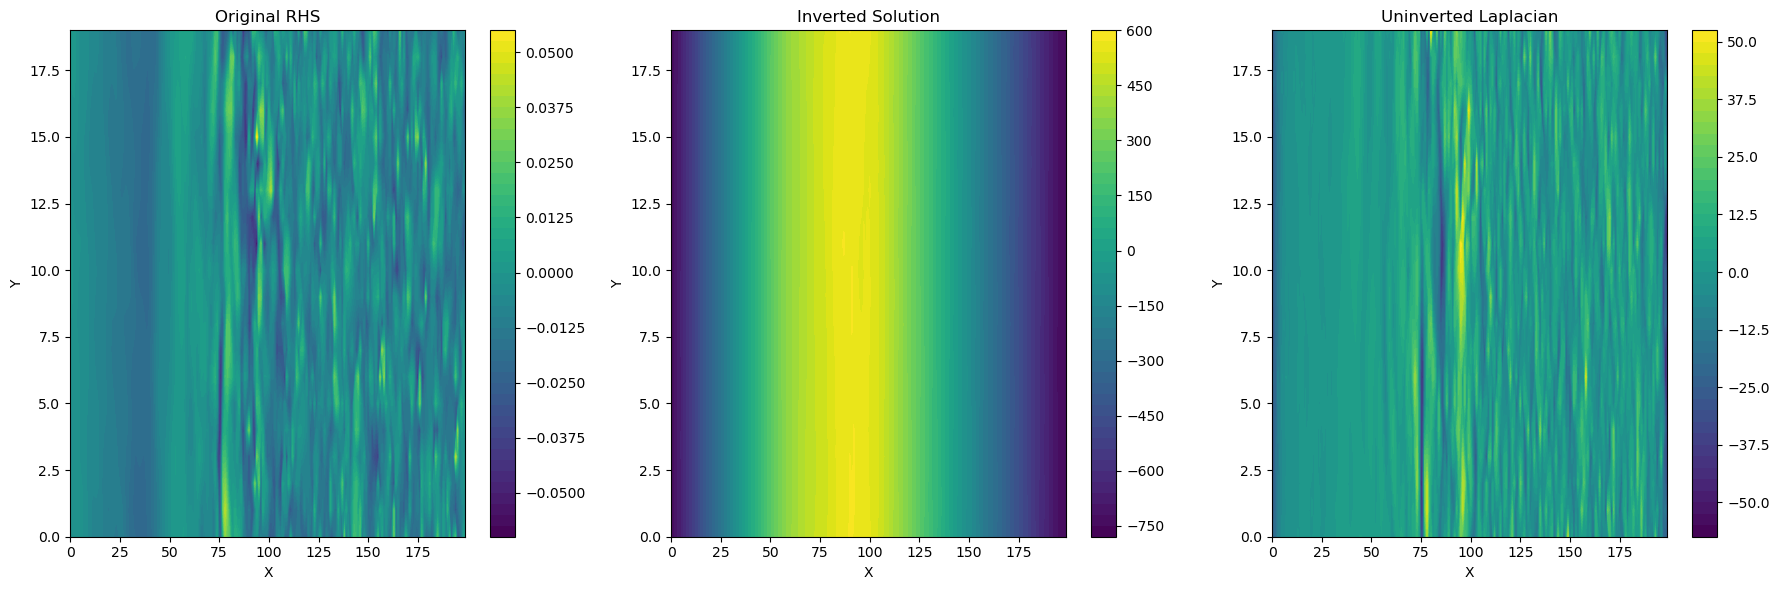

In [84]:
#INVERTING 
RHS=rho*B; # RHS=ddz(RHS)
# integral_x = np.trapz(RHS, axis=2)
# integral_y = np.trapz(integral_x, axis=1)
# integral_z = np.trapz(integral_y, axis=0)   
# RHS /= integral_z # Normalize RHS such that the integral = 1

Nz,Ny,Nx=RHS.shape 

# Inversion parameters
Lx = 1000 * Nx
Ly = 1000 * Ny
Lz = 1000 * Nz
dx = Lx / Nx
dy = Ly / Ny
dz = Lz / Nz #***z should be stretched

# Invert and compute Laplacian
f = invert_laplacian_3d(RHS, dx, dy, dz)
# f *= integral_z
laplacian_f = compute_laplacian_3d(f, dx, dy)

####################################################################################################

# Create figure and GridSpec
fig = plt.figure(figsize=(18, 6))
gs = fig.add_gridspec(1, 3)  # 1 row, 3 columns

# Create subplots using GridSpec
ax1 = fig.add_subplot(gs[0])  # First plot
ax2 = fig.add_subplot(gs[1])  # Second plot
ax3 = fig.add_subplot(gs[2])  # Third plot

# Plot Original RHS
cont1=ax1.contourf(ddz_stretch(RHS)[11], levels=50)
# cont1=ax1.contourf(RHS[11], levels=50)
fig.colorbar(cont1)
ax1.set_title("Original RHS")

# Plot Inverted
cont2=ax2.contourf(f[11], levels=50)
fig.colorbar(cont2)
ax2.set_title("Inverted Solution")

# Plot Un-inverted Laplacian
cont3=ax3.contourf(laplacian_f[11], levels=50)
fig.colorbar(cont3)
ax3.set_title("Uninverted Laplacian")

#Axises
ax1.set_xlabel('X');ax1.set_ylabel('Y')
ax2.set_xlabel('X');ax2.set_ylabel('Y')
ax3.set_xlabel('X');ax3.set_ylabel('Y')

# Adjust layout to avoid overlap
plt.tight_layout()



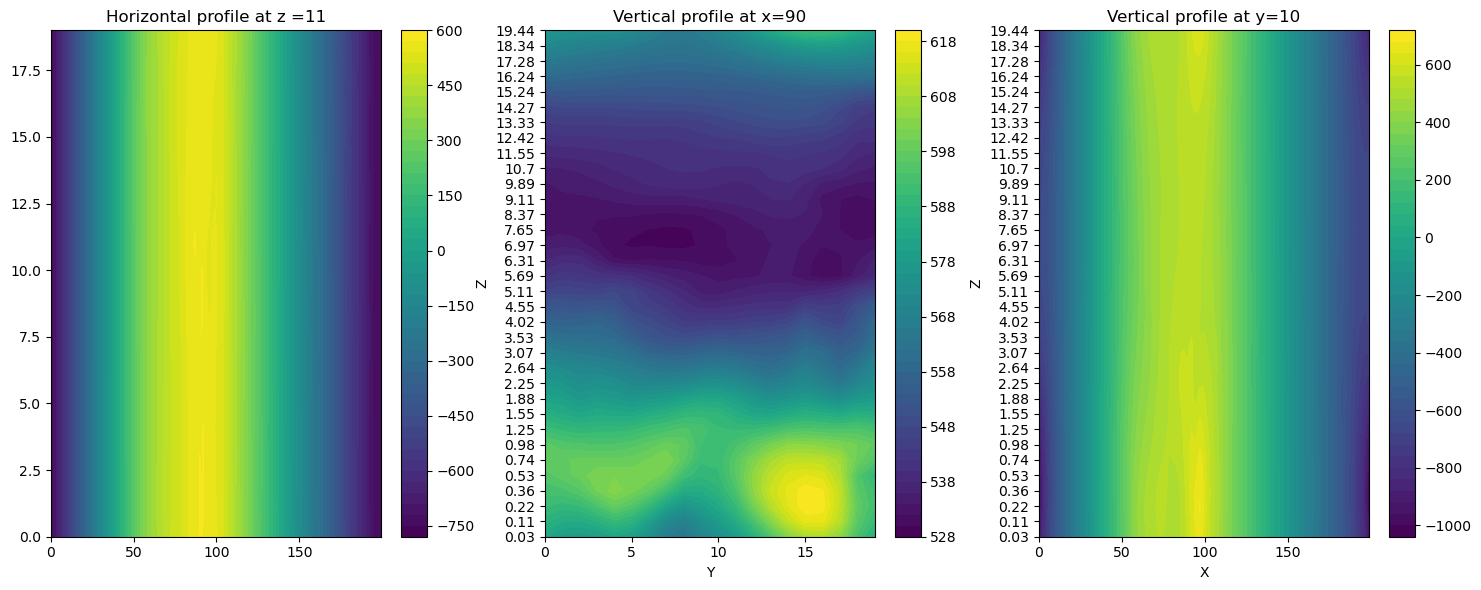

In [41]:
import matplotlib.pyplot as plt

xind=280
yind=50

xind = 90 #Uncomment for partial run
yind = 10  

# Create a 1x3 subplot layout
fig, axs = plt.subplots(1, 3, figsize=(15, 6))  # 1 row, 3 columns

# Original contour plot
cont1 = axs[0].contourf(f[11], levels=50)  # Assuming f[11] is your 2D slice
fig.colorbar(cont1, ax=axs[0])  # Correct placement of colorbar for axs[0]
axs[0].set_title(f"Horizontal profile at z ={11}")

# Plot for vertical profile at xind
cont2 = axs[1].contourf(f[:, :, xind], levels=50)
axs[1].set_xlabel('Y')
axs[1].set_ylabel('Z')
axs[1].set_title(f'Vertical profile at x={xind}')
fig.colorbar(cont2, ax=axs[1])  # Correct placement of colorbar for axs[1]

# Plot for vertical profile at yind
cont3 = axs[2].contourf(f[:, yind, :], levels=50)
axs[2].set_xlabel('X')
axs[2].set_ylabel('Z')
axs[2].set_title(f'Vertical profile at y={yind}')
fig.colorbar(cont3, ax=axs[2])  # Correct placement of colorbar for axs[2]

# Show the plot
plt.tight_layout()  # Adjust spacing



#ylabels
zh=np.round(data['zh'].values,2)
axs[1].set_yticks(range(len(zh)));  # Set the number of ticks (corresponding to `zh`)
axs[1].set_yticklabels(zh);

zh=np.round(data['zh'].values,2)
axs[2].set_yticks(range(len(zh)));  # Set the number of ticks (corresponding to `zh`)
axs[2].set_yticklabels(zh);


In [43]:
def ddz(f):
    # f=f.data
    dz=data['zh'].values
    dz=dz.copy()[:, np.newaxis, np.newaxis]
    
    ddz=np.zeros_like(f)
    ddz[1:-1, :, :] = (f[2:, :, :] - f[:-2, :, :]) / (2 * dz[1:-1])
    ddz[0, :, :] = (f[1, :, :] - f[0, :, :]) / dz[0]  # Forward difference 
    ddz[-1, :, :] = (f[-1, :, :] - f[-2, :, :]) / dz[-1]  # Backward difference 
    return ddz

#Dynamic Buoyancy
dyn_buoy=B-(1/rho)*ddz(f)

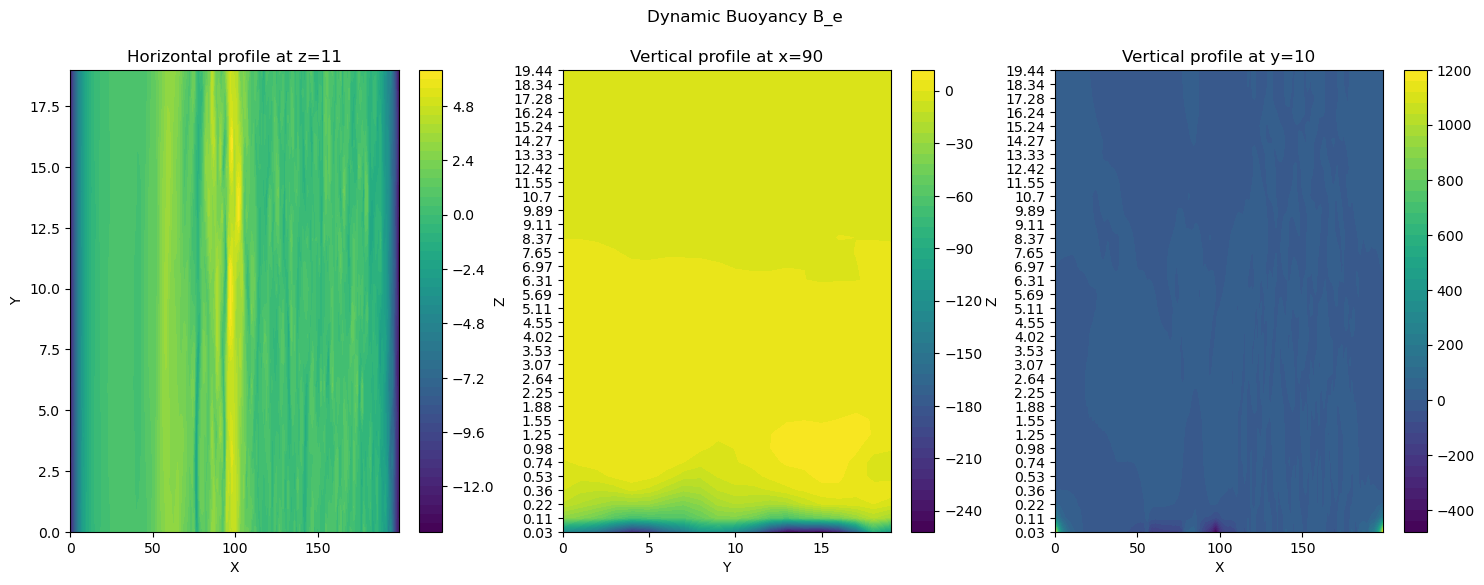

In [45]:
import matplotlib.pyplot as plt

# Set the indices for x and y for the second and third plots
# xind=280
# yind=50

xind = 90 #uncomment for partial run
yind = 10  

# Create a 1x3 subplot layout
fig, axs = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

# First subplot: dyn_buoy[11, :, :]
c1 = axs[0].contourf(dyn_buoy[11, :, :], levels=50)
axs[0].set_xlabel('X')
axs[0].set_ylabel('Y')
axs[0].set_title('Horizontal profile at z=11')
fig.colorbar(c1, ax=axs[0])

# Second subplot: vertical profile at xind
c2 = axs[1].contourf(dyn_buoy[:, :, xind], levels=50)
axs[1].set_xlabel('Y')
axs[1].set_ylabel('Z')
axs[1].set_title(f'Vertical profile at x={xind}')
fig.colorbar(c2, ax=axs[1])

# Third subplot: vertical profile at yind
c3 = axs[2].contourf(dyn_buoy[:, yind, :], levels=50)
axs[2].set_xlabel('X')
axs[2].set_ylabel('Z')
axs[2].set_title(f'Vertical profile at y={yind}')
fig.colorbar(c3, ax=axs[2])



# Show the plot
fig.suptitle('Dynamic Buoyancy B_e')



#ylabels
zh=np.round(data['zh'].values,2)
axs[1].set_yticks(range(len(zh)));  # Set the number of ticks (corresponding to `zh`)
axs[1].set_yticklabels(zh);

zh=np.round(data['zh'].values,2)
axs[2].set_yticks(range(len(zh)));  # Set the number of ticks (corresponding to `zh`)
axs[2].set_yticklabels(zh);

In [15]:
#####################################################
#CREATE STORAGE XARRAY FOR DYNAMIC BUOYANCY AND PB

time_steps = len(data['time'])
z_size = B.shape[0]
y_size = B.shape[1]
x_size = B.shape[2]

PB_data = np.zeros((time_steps, z_size, y_size, x_size))  
dyn_buoy_data = np.zeros((time_steps, z_size, y_size, x_size))


dyn_buoy_ds = xr.Dataset(
    {
        'PB': (['time', 'z', 'y', 'x'], PB_data),
        'dyn_buoy': (['time', 'z', 'y', 'x'], dyn_buoy_data)
        
    },
    coords={
        'time': np.arange(time_steps),  # Example time steps
        'zh': data['zh'].values,  # Z coordinates
        'yh': data['yh'].values,  # Y coordinates
        'xh': data['xh'].values   # X coordinates
    }
)

In [ ]:
#LOOP FOR MAKING DATA ARRAY FOR MULTIPLE TIMES
for t in np.arange(len(data['time'])):
    print(f'current time {t}')
    #CALCULATING
    B=data['buoyancy'].isel(time=t)
    rho=data['rho'].isel(time=t)
    RHS=rho*B
    # integral_x = np.trapz(RHS, axis=2)
    # integral_y = np.trapz(integral_x, axis=1)
    # integral_z = np.trapz(integral_y, axis=0)   
    # RHS /= integral_z # Normalize RHS such that the integral = 1
    f = invert_laplacian_3d(RHS, dx, dy, dz)
    f *= integral_z
    dyn_buoy=B-(1/rho)*ddz(f)

    #STORING
    dyn_buoy_ds['dyn_buoy'][t, :, :, :] = dyn_buoy.data
    dyn_buoy_ds['PB'][t, :, :, :] = f
dyn_buoy_ds.to_netcdf('buoyancy_calculations.nc')
print('done')


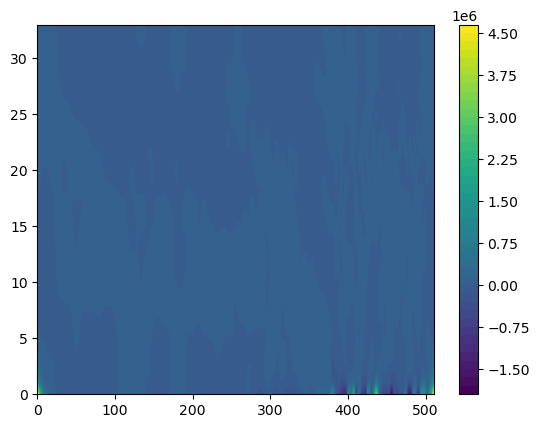

In [19]:
t=110
view=dyn_buoy_ds['dyn_buoy'][t,:,50,:]
# view=data['buoyancy'][t,:,50,:]

plt.contourf(view,levels=50)
plt.colorbar()

Text(0.5, 1.0, 'Dyn Buoyancy at Time 80 (Y=50)')

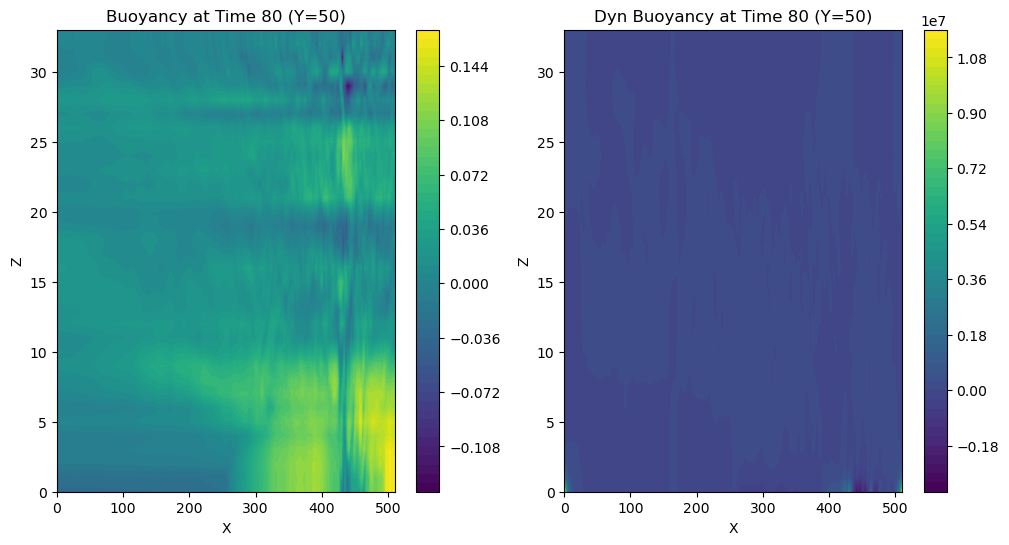

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming you have dyn_buoy_ds and it's already loaded
t = 80

view = data['buoyancy'][t, :, 50, :]
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

cs1 = axs[0].contourf(view, levels=50)
fig.colorbar(cs1, ax=axs[0])
axs[0].set_xlabel('X')
axs[0].set_ylabel('Z')
axs[0].set_title(f'Buoyancy at Time {t} (Y=50)')

######
view2 = dyn_buoy_ds['dyn_buoy'][t, :, 50, :]  # Example with different Y index
cs2 = axs[1].contourf(view2, levels=50)
fig.colorbar(cs2, ax=axs[1])
axs[1].set_xlabel('X')
axs[1].set_ylabel('Z')
axs[1].set_title(f'Dyn Buoyancy at Time {t} (Y=50)')

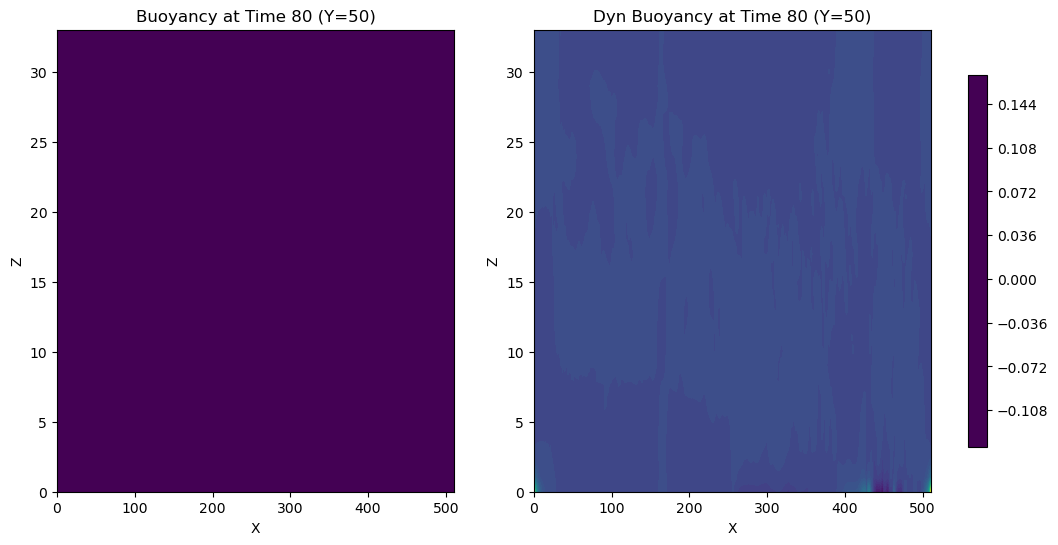

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming you have dyn_buoy_ds and it's already loaded
t = 80

# Extract data
view = data['buoyancy'][t, :, 50, :]
view2 = dyn_buoy_ds['dyn_buoy'][t, :, 50, :]

# Determine the global min and max values across both datasets
vmax1 = max(view.max(), view2.max())  # Global max

# Create a 1x2 subplot layout
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot the first contour plot
cs1 = axs[0].contourf(view, levels=50,vmax=vmax1)  # Apply vmin and vmax for the same color scale
axs[0].set_xlabel('X')
axs[0].set_ylabel('Z')
axs[0].set_title(f'Buoyancy at Time {t} (Y=50)')

# Plot the second contour plot
cs2 = axs[1].contourf(view2, levels=50, vmax=vmax1)  # Apply vmin and vmax for the same color scale
axs[1].set_xlabel('X')
axs[1].set_ylabel('Z')
axs[1].set_title(f'Dyn Buoyancy at Time {t} (Y=50)')


# # Create one colorbar for both plots
fig.colorbar(cs1, ax=axs, orientation='vertical', fraction=0.02, pad=0.04)

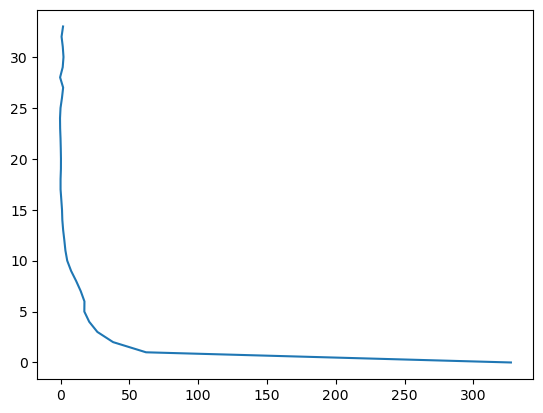

In [22]:
view = data['buoyancy'][t, :, :, :]
view2 = dyn_buoy_ds['dyn_buoy'][t, :, :, :]
hey=view2.mean(dim=('x','y')).values-view.mean(dim=('xh','yh')).values
plt.plot(hey,np.arange(len(hey)));